# 1. Vector applications

## 1A. Correlation and cosine similarity

A _correlation coefficient_ is a single number that quantifies the linear relationshop between two variables. Correlation coefficients range from -1 to +1, with -1 indicating a perfect negative relationship, +1 a perfect positive relationship, and 0 indicating no linear relationship. The correlation coefficient requires some normalizations to be in the expected range of -1 to +1.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
plt.rcParams.update({'font.size':14})

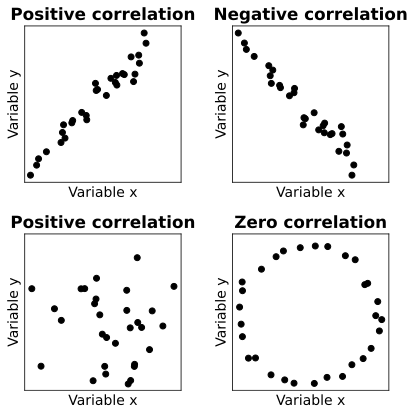

In [11]:
N = 30
x = np.linspace(0, 10, N) + np.random.randn(N)
y = x + np.random.randn(N)

_, axs = plt.subplots(2,2, figsize=(6,6))

# Positive correlation
axs[0,0].plot(x,y, 'ko')
axs[0,0].set_title('Positive correlation', fontweight='bold')
axs[0,0].set_xlabel('Variable x')
axs[0,0].set_ylabel('Variable y')
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])
axs[0,0].axis('square')

# Negative correlation
axs[0,1].plot(x,-y, 'ko')
axs[0,1].set_title('Negative correlation', fontweight='bold')
axs[0,1].set_xlabel('Variable x')
axs[0,1].set_ylabel('Variable y')
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])
axs[0,1].axis('square')

# Zero correlation
axs[1,0].plot(np.random.randn(N), np.random.randn(N), 'ko')
axs[1,0].set_title('Positive correlation', fontweight='bold')
axs[1,0].set_xlabel('Variable x')
axs[1,0].set_ylabel('Variable y')
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])
axs[1,0].axis('square')

# Zero correlation
x = np.cos(np.linspace(0,2*np.pi,N)) + np.random.randn(N)/20
y = np.sin(np.linspace(0,2*np.pi,N)) + np.random.randn(N)/20
axs[1,1].plot(x,y, 'ko')
axs[1,1].set_title('Zero correlation', fontweight='bold')
axs[1,1].set_xlabel('Variable x')
axs[1,1].set_ylabel('Variable y')
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])
axs[1,1].axis('square')

plt.tight_layout()
plt.savefig('Figure_04_01.png', dpi=300)
plt.show()

Those two normalizations are:

1. _Mean center each variable_
    Mean centering means to subtract the average value from each data value.

2. _Divide the dot prodcut by the product of the vector norms.
    This devisive normalization cancels the measurement units and scales the maximum possible correlation magnitude to [1].

The next equation shows the Pearson correlation coefficient.
$$
    \rho = \frac{
        \sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})        
    }{
        \sqrt{\sum_{i=1}^n (x_i-\bar{x})^2} \sqrt{\sum_{i=1}^n (y_i-\bar{y})^2}
    }
$$

The previous equation can be rewritten using the linear algebra dot-product notation.
$$
    \rho = \frac{\tilde{x}^T\tilde{y}}{\|\tilde{x}\|\|\tilde{y}\|}
$$
where $\tilde{x}$ is the mean-centered version of $x$, i.e., variable $x$ with _mean centering_ normalization.

Another method to assess similarity between two variables is _cosine similarity_. It is the geometric interpretation for the dot product solved for the cosine term, with the assumption that the variables have already been mean centered.
$$
    \cos(\theta _{x,y}) = \frac{\alpha}{\|x\|\|y\|}
$$
where $\alpha$ is the dot prodcut between $x$ and $y$.



### 1A1. Exercise 4-1

In [17]:
import numpy as np

def pearson_correlation(v, w):
    v_centered = v - np.ones(len(v)) * v.mean()
    w_centered = w - np.ones(len(w)) * w.mean()
    
    numer = np.sum(v_centered * w_centered)
    denom = np.sqrt(np.sum(v_centered**2)) * np.sqrt(np.sum(w_centered**2))
    return numer/denom

def corre_and_cosine_similarity(v, w):
    cos = np.dot(v, w) / (np.linalg.norm(v)*np.linalg.norm(w))
    
    v_centered = v - np.ones(len(v)) * v.mean()
    w_centered = w - np.ones(len(w)) * w.mean()
    cor = np.dot(v_centered, w_centered)/(np.linalg.norm(v_centered)*np.linalg.norm(w_centered))
    
    return cor, cos

v = np.random.randn(10)
w = np.random.randn(10)

print(pearson_correlation(v, w), corre_and_cosine_similarity(v, w))
print(np.corrcoef(v,w)[0,1])

-0.10310184961371258 (np.float64(-0.10310184961371258), np.float64(-0.09429831570737393))
-0.1031018496137126


### 1A2. Exercise 4-2

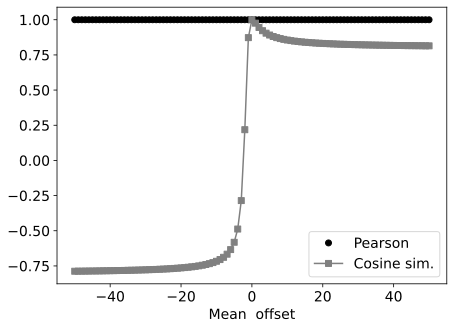

In [21]:
v = np.arange(4, dtype=float)
offsets = np.arange(-50,51)

results = np.zeros((len(offsets),2))  #[correlation, cosine]

for i in range(len(offsets)):
    results[i,:] = corre_and_cosine_similarity(v, v+offsets[i])
    
plt.figure(figsize=(7,5))

plt.plot(offsets, results[:,0], 'ko', label='Pearson')
plt.plot(offsets, results[:,1], color='gray', marker='s', label='Cosine sim.')
plt.xlabel('Mean  offset')
plt.legend()
plt.savefig('Figure_04_02.png', dpi=300)
plt.show()

### 1A3. Exercise 4-3

In [ ]:
from scipy.stats import pearsonr
# check the function 'pearsonr'

### 1A4. Exercise 4-4

C:\Users\carabalm\AppData\Local\Temp\ipykernel_17316\3764625486.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


My function: 0.0636 +/- 0.0050 s


C:\Users\carabalm\AppData\Local\Temp\ipykernel_17316\3764625486.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


Built-in function: 2.2834 +/- 0.1062 s


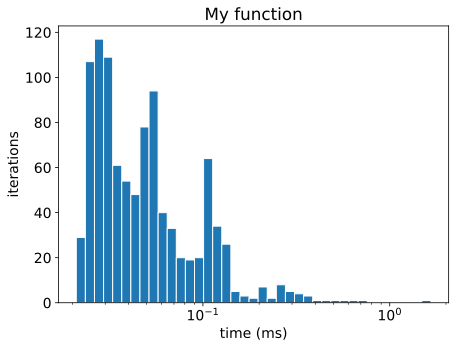

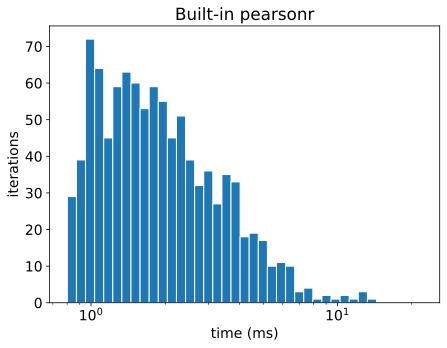

In [44]:
import time
import numpy as np
import matplotlib.pyplot as plt

def dot_p_correlation(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return np.dot(xc, yc) / (np.linalg.norm(xc) * np.linalg.norm(yc))

n = 1000
comp_time = []
for _ in range(n):
    x = np.random.randn(500)
    y = np.random.randn(500)
    t0 = time.perf_counter()
    dot_p_correlation(x, y)
    comp_time.append((time.perf_counter() - t0) * 1e3)

fig1 = plt.figure(figsize=(7, 5))
plt.hist(comp_time, bins=np.logspace(np.log10(min(comp_time)),
                                     np.log10(max(comp_time)), 40),
         edgecolor='white')
plt.xscale('log')
plt.xlabel('time (ms)')
plt.ylabel('iterations')
plt.title('My function')
fig1.savefig('My_correlation_function.png', dpi=300)
fig1.show()

comp_time = np.array(comp_time)
p = comp_time.mean()
std_error = comp_time.std() / np.sqrt(n)

print(f"My function: {p:.4f} +/- {1.96*std_error:.4f} s")

comp_time = []
for _ in range(n):
    x = np.random.randn(500)
    y = np.random.randn(500)
    t0 = time.perf_counter()
    pearsonr(x, y)
    comp_time.append((time.perf_counter() - t0) * 1e3)

fig2 = plt.figure(figsize=(7, 5))
plt.hist(comp_time, bins=np.logspace(np.log10(min(comp_time)),
                                     np.log10(max(comp_time)), 40),
         edgecolor='white')
plt.xscale('log')
plt.xlabel('time (ms)')
plt.ylabel('iterations')
plt.title('Built-in pearsonr')
fig2.savefig('Built-ind pearsonr.png', dpi=300)
fig2.show()

comp_time = np.array(comp_time)
p = comp_time.mean()
std_error = comp_time.std() / np.sqrt(n)
print(f"Built-in function: {p:.4f} +/- {1.96*std_error:.4f} s")

## 1B. Time series filtering and feature detection

Filtering is essentially a feature-detection method, whereby a template, called a _kernel_ in the parlance of filtering, is matched against portions of a time series signal, and the result of filtering is another time serires that indicates how much the characteristics of the signal match the characteristics of the kernel.

The mechanism of filtering is to compute the dot product between the kernel and the time series signal. 

### 1B1. Exercise 4-5

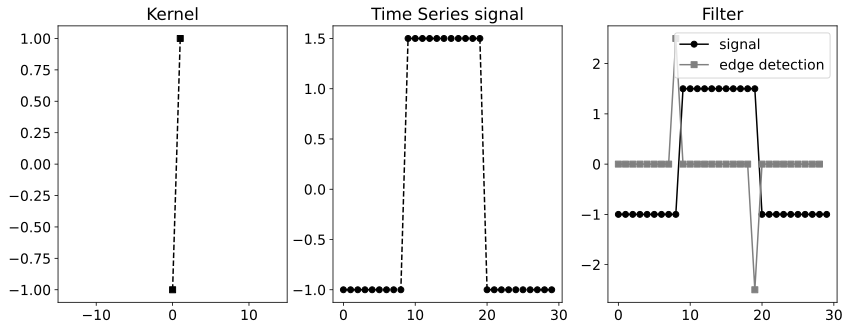

In [87]:

kernel = np.array([-1,1])
t_s_signal = np.array([-1 if i < 9 or i > 19 else 1.5 for i in range(30)])

filter = []
for i in range(len(t_s_signal)):
    if i < len(t_s_signal)-1:
        portion = np.array([t_s_signal[i],t_s_signal[i+1]])
        filter.append(np.dot(kernel, portion))

_, axs = plt.subplots(1, 3, figsize=(14,5))

axs[0].plot(kernel, 'ks--')
axs[0].set_xlim(-15, 15)
axs[0].set_title('Kernel')

axs[1].plot(t_s_signal, 'ko--', label='signal')
axs[1].set_title('Time Series signal')

axs[2].plot(t_s_signal, 'ko-', label='signal')
axs[2].plot(filter, 's-', color='gray', label='edge detection')
axs[2].set_title('Filter')
axs[2].legend()

plt.savefig('Figure_04_05.png',dpi=300)
plt.show()


### 1B2. Exercise 4-6

0.9999999999999999


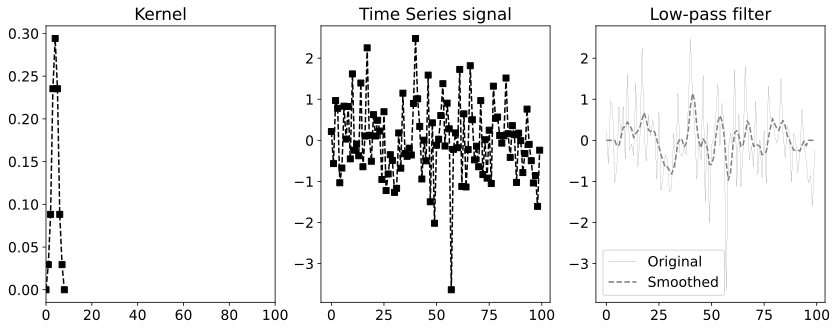

In [ ]:
# Kernel
kernel = np.array([0., 0.1, 0.3, 0.8, 1., 0.8, 0.3, 0.1, 0])
kernel /= kernel.sum()  # weighting the kernel 
print(kernel.sum())     # sum = 1.0
half_N_Kernel = len(kernel)//2

# Signal
N = 100
signal = np.random.randn(N)

# Filterd signal
filt_signal = np.zeros(N)
for t in range(half_N_Kernel+1, N-half_N_Kernel):
    filt_signal[t] = np.dot(kernel, signal[t-half_N_Kernel-1:t+half_N_Kernel])

_, axs = plt.subplots(1, 3, figsize=(14,5))

axs[0].plot(kernel, 'ks--')
axs[0].set_xlim(0, 100)
axs[0].set_title('Kernel')

axs[1].plot(signal, 'ks--', label='signal')
axs[1].set_title('Time Series signal')

axs[2].plot(signal, 'k-', linewidth=0.1, label='Original')
axs[2].plot(filt_signal, '--', color='gray', label='Smoothed')
axs[2].legend()
axs[2].set_title('Low-pass filter')

plt.savefig('Figure_04_06.png',dpi=300)
plt.show()


### 1B3. Exercise 4-7

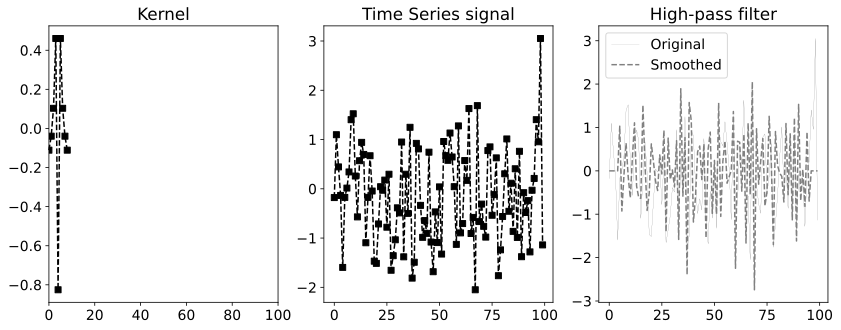

In [114]:
# Kernel
kernel = np.array([0., 0.1, 0.3, 0.8, -1., 0.8, 0.3, 0.1, 0])
kernel /= kernel.sum()
kernel -= kernel.mean()  # mean centered 
half_N_Kernel = len(kernel)//2

# Signal
N = 100
signal = np.random.randn(N)

# Filterd signal
filt_signal = np.zeros(N)
for t in range(half_N_Kernel+1, N-half_N_Kernel):
    filt_signal[t] = np.dot(kernel, signal[t-half_N_Kernel-1:t+half_N_Kernel])

_, axs = plt.subplots(1, 3, figsize=(14,5))

axs[0].plot(kernel, 'ks--')
axs[0].set_xlim(0, 100)
axs[0].set_title('Kernel')

axs[1].plot(signal, 'ks--', label='signal')
axs[1].set_title('Time Series signal')

axs[2].plot(signal, 'k-', linewidth=0.1, label='Original')
axs[2].plot(filt_signal, '--', color='gray', label='Smoothed')
axs[2].legend()
axs[2].set_title('High-pass filter')

plt.savefig('Figure_04_07.png',dpi=300)
plt.show()


## 1C. k-Means clustering

_k-means clustering_ is an unsupervised method of classifying multivariate data into a relatively small number of groups, or categories, based on minimizing distance to the group center.

__Algorithm__
1. Initialize _k_ centroids as random points in the data space. Eache centroid is a _class_ or category, and the next steps will assign each data observation to each class.
2. Compute the Euclidena distance between each data observation and each centroid.
3. Assign each data observation to the group with the closest centroid.
4. Update each centroid as the average of all data observations assigned to that centroid.
5. Repeat steps 2-4 until a convergence criteria is satisfied, or for _N_ iterations.

### 1C1. Exercise 4-8

C:\Users\carabalm\AppData\Local\Temp\ipykernel_17316\4266271130.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


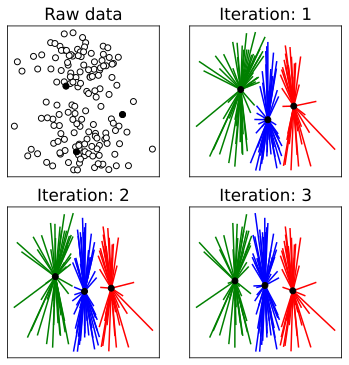

In [157]:
# Generate data
samples = 50
blur = 1    # blur around centroid (std units)
a = [np.random.randn(samples)*blur, np.random.rand(samples)*blur]
b = [np.random.randn(samples)*blur, np.random.rand(samples)*blur]
c = [np.random.randn(samples)*blur, np.random.rand(samples)*blur]

# concatenate into a matrix
data = np.concatenate((a,b,c), axis=1).T

# plot data
fig, axs = plt.subplots(2, 2, figsize=(6,6))
# axs = axs.flatten()
line_colors = ['r', 'g', 'b']

axs[0,0].plot(data[:,0], data[:,1], 'ko', markerfacecolor='w')
axs[0,0].set_title('Raw data')
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])

# Step 1. Initialize k random cluster centroids
k = 3   # fix value; use optimization techniques to find the optimal number of clusters, e.g., spectral clustering or Louvain method
random_idx = np.random.choice(range(samples), k, replace=False)
centroids = data[random_idx,:]      # k random centroids

axs[0,0].plot(centroids[:,0], centroids[:,1], 'ko')

# Step 5. Repeat steps 2-4
for iter in range(3):
    # Step 2. Compute the distance between each data observation and each cluster centroid,
    dists = np.zeros((data.shape[0], k))
    for cls_i in range(k):
        dists[:, cls_i] = np.sqrt(np.sum((data-centroids[cls_i,:])**2, axis=1))

    # Step 3. Assign each data observation to the group with minimum distance
    group_idx = np.argmin(dists, axis=1)    #np.argmin returns the min_index while np.min returns the min_value 


    # Step 4. Recompute the centroids as the mean of all data points within the class
    for k_i in range(k):
        centroids[k_i, :] = [np.mean(data[group_idx==k_i, 0]),
                            np.mean(data[group_idx==k_i, 1])]
    
    if iter == 0:
        axs_0, axs_1 = 0, 1
    if iter == 1:
        axs_0, axs_1 = 1, 0   
    if iter == 2:
        axs_0, axs_1 = 1, 1
    for i in range(len(data)):
        axs[axs_0,axs_1].plot([data[i,0], centroids[group_idx[i],0]], [data[i,1], centroids[group_idx[i],1]], color=line_colors[group_idx[i]])
    axs[axs_0,axs_1].plot(centroids[:,0], centroids[:,1], 'ko')
    axs[axs_0,axs_1].set_title(f'Iteration: {iter+1}')
    axs[axs_0,axs_1].set_xticks([])
    axs[axs_0,axs_1].set_yticks([])

fig.savefig('Figure_04_03.png', dpi=300)
fig.show()

### 1C2. Exercise 4-9

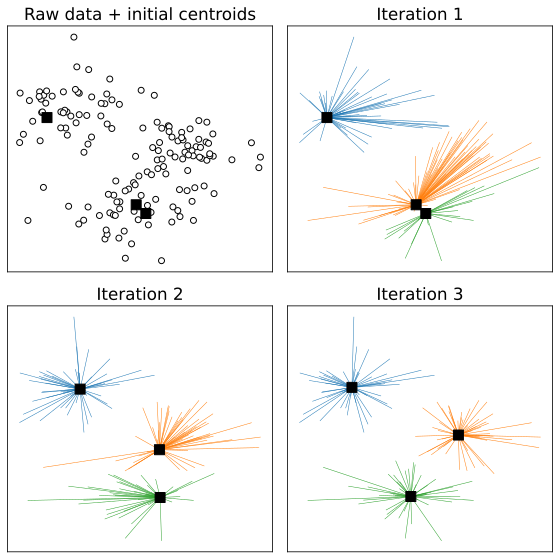

In [158]:
import numpy as np
import matplotlib.pyplot as plt

samples, k, n_iter = 50, 3, 3

a = [np.random.randn(samples) + 1, np.random.randn(samples) + 3]
b = [np.random.randn(samples) + 5, np.random.randn(samples) + 1]
c = [np.random.randn(samples) + 3, np.random.randn(samples) - 2]
data = np.concatenate((a, b, c), axis=1).T

colors = plt.cm.tab10(np.arange(k))          # never desyncs from k
rng = np.random.default_rng()
centroids = data[rng.choice(data.shape[0], k, replace=False), :].copy()

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs = axs.flatten()

axs[0].plot(data[:, 0], data[:, 1], 'ko', markerfacecolor='w')
axs[0].plot(centroids[:, 0], centroids[:, 1], 'ks', markersize=10)
axs[0].set_title('Raw data + initial centroids')

for it in range(n_iter):
    ax = axs[it + 1]

    dists = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2)
    group_idx = np.argmin(dists, axis=1)

    for i in range(len(data)):                # draw BEFORE updating
        ax.plot([data[i, 0], centroids[group_idx[i], 0]],
                [data[i, 1], centroids[group_idx[i], 1]],
                color=colors[group_idx[i]], lw=0.5)
    ax.plot(centroids[:, 0], centroids[:, 1], 'ks', markersize=10)
    ax.set_title(f'Iteration {it + 1}')

    for ki in range(k):
        members = data[group_idx == ki]
        if members.size:                      # empty cluster: leave centroid put
            centroids[ki] = members.mean(axis=0)

for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
fig.savefig('Figure_04_03b.png', dpi=300)
plt.show()